# 5주차 코드 과제: CNN 개선 실험

CIFAR-10 대신 **Fashion-MNIST** 의류 이미지를 사용하여 기본 CNN과 개선 CNN을 비교합니다. 개선 모델에는 Conv layer 추가, Batch Normalization, Dropout, He initialization, AdamW와 Early Stopping을 적용합니다.

In [1]:
%matplotlib inline
import copy
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


## 1. Fashion-MNIST 데이터 준비

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),
])
full_train = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
full_test = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

# CPU에서도 짧게 재현되도록 고정된 subset을 사용합니다.
subset_indices = torch.randperm(len(full_train), generator=torch.Generator().manual_seed(SEED))[:14000]
train_val = Subset(full_train, subset_indices.tolist())
train_data, val_data = random_split(train_val, [12000, 2000], generator=torch.Generator().manual_seed(SEED))
test_indices = torch.randperm(len(full_test), generator=torch.Generator().manual_seed(SEED))[:3000]
test_data = Subset(full_test, test_indices.tolist())

loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True, generator=loader_generator, num_workers=0)
val_loader = DataLoader(val_data, batch_size=256, shuffle=False, num_workers=0)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False, num_workers=0)
print(f'train={len(train_data)}, validation={len(val_data)}, test={len(test_data)}')


  0%|          | 0.00/26.4M [00:00<?, ?B/s]


  0%|          | 32.8k/26.4M [00:00<03:54, 112kB/s]


  0%|          | 65.5k/26.4M [00:00<04:00, 110kB/s]


  0%|          | 131k/26.4M [00:00<02:37, 167kB/s] 


  1%|          | 197k/26.4M [00:01<03:21, 130kB/s]

...


100%|██████████| 4.42M/4.42M [00:16<00:00, 289kB/s]


100%|██████████| 4.42M/4.42M [00:16<00:00, 267kB/s]


  0%|          | 0.00/5.15k [00:00<?, ?B/s]


100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]

train=12000, validation=2000, test=3000


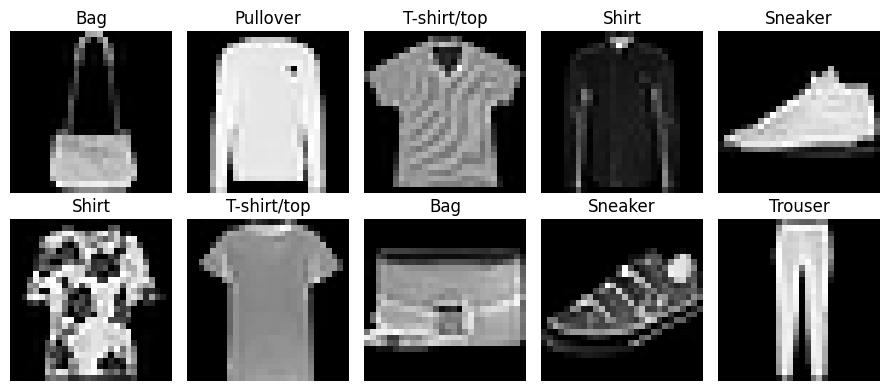

In [3]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for image, label, ax in zip(images[:10], labels[:10], axes.ravel()):
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(class_names[label.item()])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 2. Baseline CNN과 개선 CNN

In [4]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(32 * 7 * 7, 64), nn.ReLU(), nn.Linear(64, 10))

    def forward(self, x):
        return self.classifier(self.features(x))


class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.10),
            nn.Conv2d(32, 64, 3, padding=1, bias=False), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.20),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * 7 * 7, 128), nn.ReLU(), nn.Dropout(0.35), nn.Linear(128, 10)
        )
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
            if module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, x):
        return self.classifier(self.features(x))

print('Baseline parameters:', sum(p.numel() for p in BaselineCNN().parameters()))
print('Improved parameters:', sum(p.numel() for p in ImprovedCNN().parameters()))

Baseline parameters: 105866
Improved parameters: 431018


## 3. 학습 함수와 Early Stopping

In [5]:
criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    loss_sum, correct, count = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss_sum += criterion(logits, y).item() * y.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            count += y.size(0)
    return loss_sum / count, correct / count

def train_model(model, optimizer, max_epochs=8, patience=2):
    model.to(device)
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_loss, best_state, wait = float('inf'), None, 0
    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss, count = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * y.size(0)
            count += y.size(0)
        train_loss = running_loss / count
        val_loss, val_acc = evaluate(model, val_loader)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        print(f'epoch {epoch:02d} | train loss {train_loss:.4f} | val loss {val_loss:.4f} | val acc {val_acc:.4f}')
        if val_loss < best_loss - 1e-4:
            best_loss, best_state, wait = val_loss, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience:
                print(f'Early stopping at epoch {epoch}')
                break
    model.load_state_dict(best_state)
    return history

## 4. 동일 조건 비교 실험

In [6]:
torch.manual_seed(SEED)
baseline = BaselineCNN()
baseline_history = train_model(baseline, torch.optim.Adam(baseline.parameters(), lr=1e-3))
baseline_test_loss, baseline_test_acc = evaluate(baseline, test_loader)
print(f'Baseline test loss={baseline_test_loss:.4f}, accuracy={baseline_test_acc:.4f}')

torch.manual_seed(SEED)
improved = ImprovedCNN()
improved_history = train_model(
    improved, torch.optim.AdamW(improved.parameters(), lr=1e-3, weight_decay=1e-4)
)
improved_test_loss, improved_test_acc = evaluate(improved, test_loader)
print(f'Improved test loss={improved_test_loss:.4f}, accuracy={improved_test_acc:.4f}')
torch.save(improved.state_dict(), 'FashionMNIST_improved_cnn.pth')

epoch 01 | train loss 0.8595 | val loss 0.5785 | val acc 0.7800


epoch 02 | train loss 0.4976 | val loss 0.4680 | val acc 0.8275


epoch 03 | train loss 0.4312 | val loss 0.4011 | val acc 0.8545


epoch 04 | train loss 0.3801 | val loss 0.3951 | val acc 0.8550


epoch 05 | train loss 0.3627 | val loss 0.3715 | val acc 0.8635


...

epoch 05 | train loss 0.3726 | val loss 0.3240 | val acc 0.8850


epoch 06 | train loss 0.3534 | val loss 0.3069 | val acc 0.8875


epoch 07 | train loss 0.3336 | val loss 0.3233 | val acc 0.8825


epoch 08 | train loss 0.3118 | val loss 0.3044 | val acc 0.8890


Improved test loss=0.3092, accuracy=0.8890


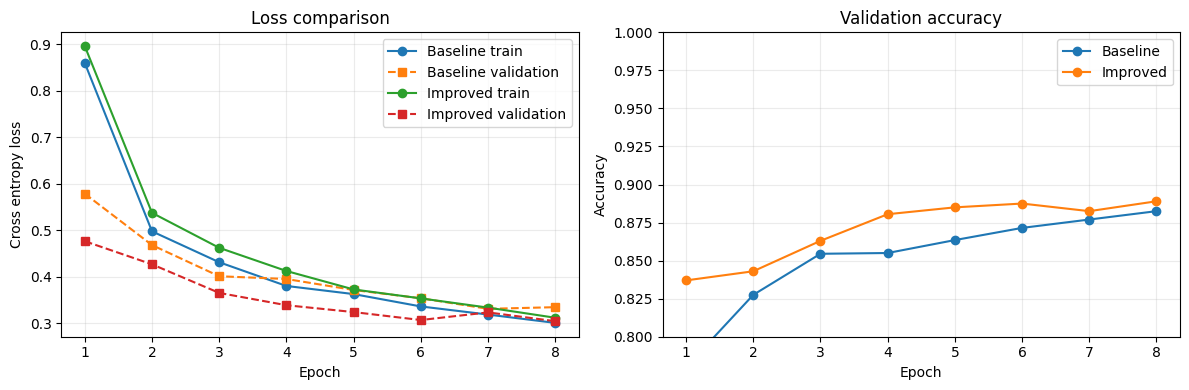

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, hist in [('Baseline', baseline_history), ('Improved', improved_history)]:
    epochs = range(1, len(hist['train_loss']) + 1)
    axes[0].plot(epochs, hist['train_loss'], marker='o', label=f'{name} train')
    axes[0].plot(epochs, hist['val_loss'], marker='s', linestyle='--', label=f'{name} validation')
    axes[1].plot(epochs, hist['val_acc'], marker='o', label=name)
axes[0].set(title='Loss comparison', xlabel='Epoch', ylabel='Cross entropy loss')
axes[1].set(title='Validation accuracy', xlabel='Epoch', ylabel='Accuracy', ylim=(0.8, 1.0))
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()
plt.tight_layout()
plt.show()

## 5. 결과 분석

### 실험요약

- Baseline CNN test accuracy: 0.8703
- Improved CNN test accuracy: 0.8890
- Accuracy difference (Improved - Baseline): +0.0187

개선 CNN의 정확도가 약 1.87% 상승, test loss도 감소